# Informe Teórico Práctico 2: Árboles de Decisión (Random Forest) (Titanic)

SI3015 Fundamentos de Aprendizaje Automático, Universidad EAFIT, 2026

**Integrantes:** Julián Lara, Matías Martínez y Luis Alfonso Agudelo

**Dataset:** pasajeros del Titanic (`Titanic-Dataset.csv`)


Punto 1.3 del taller con el dataset del Titanic. En los casos 1 y 2 repetimos los casos de regresión logística (predecir `Survived`) con Random Forest. En el caso 3 el objetivo pasa a ser multiclase: predecir la **clase del pasajero** (1, 2 o 3).

**Concepto: árbol de decisión.** Divide los datos con preguntas del tipo "¿es mujer?" o "¿la edad es menor a 10?". En cada nodo elige la pregunta que deja los grupos más puros según la **impureza de Gini**, $G = 1 - \sum_k p_k^2$. Un árbol solo tiende a memorizar los datos de entrenamiento.

**Concepto: Random Forest.** Entrena muchos árboles, cada uno con una muestra aleatoria con reemplazo de las filas (**bagging**) y con un subconjunto aleatorio de columnas en cada división, y los pone a votar. Así se reduce el sobreajuste de un árbol individual. No necesita escalar los datos y captura relaciones no lineales e interacciones entre variables.

## 1. Carga del dataset

El archivo tiene 891 pasajeros y 12 columnas: identificador, si sobrevivió, clase del tiquete, nombre, sexo, edad, hermanos o pareja a bordo (`SibSp`), padres o hijos a bordo (`Parch`), número de tiquete, tarifa, cabina y puerto de embarque.

In [1]:
# Librerias que usamos en todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
SEMILLA = 42  # semilla fija para que los resultados se puedan repetir

In [2]:
# El csv esta en la raiz del repositorio, un nivel arriba de esta carpeta
df_raw = pd.read_csv("../Titanic-Dataset.csv")
print("Filas y columnas:", df_raw.shape)
print("Filas duplicadas:", df_raw.duplicated().sum())
df_raw.head()

Filas y columnas: (891, 12)
Filas duplicadas: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Tipo de dato y faltantes por columna
pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(1),
})

,tipo,faltantes,% faltantes
PassengerId,int64,0,0.0
Survived,int64,0,0.0
Pclass,int64,0,0.0
Name,str,0,0.0
Sex,str,0,0.0
Age,float64,177,19.9
SibSp,int64,0,0.0
Parch,int64,0,0.0
Ticket,str,0,0.0
Fare,float64,0,0.0


## 2. Limpieza y transformación

Hay tres columnas con faltantes:

1. **Cabin** (77 % faltante). Imputar tanto no tiene sentido. Lo que sí se puede usar es el hecho de tener o no cabina registrada, que está muy ligado a la clase del pasajero. Creamos `tiene_cabina`.
2. **Age** (cerca del 20 % faltante). Rellenarla con la mediana general mezclaría niños con adultos. El nombre trae un título (`Mr`, `Mrs`, `Miss`, `Master`) que dice mucho de la edad: `Master` se usaba para niños y `Miss` para mujeres solteras, muchas de ellas jóvenes. Llenamos la edad con la mediana de cada título y guardamos una bandera `edad_faltante`.
3. **Embarked** (2 filas). Se llenan con el puerto más frecuente (Southampton).

Además creamos `tamano_familia` (`SibSp + Parch + 1`) y `viaja_solo`, pasamos `Sex` a 0/1 y el puerto y el título a one hot. `PassengerId`, `Name`, `Ticket` y `Cabin` no se usan directamente como entrada: el identificador no significa nada y los otros tres son texto casi único por persona.

In [4]:
def limpiar_titanic(df_raw):
    df = df_raw.copy()

    # Titulo que aparece en el nombre, entre la coma y el punto: "Braund, Mr. Owen Harris" da "Mr"
    df["titulo"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
    df["titulo"] = df["titulo"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    comunes = ["Mr", "Mrs", "Miss", "Master"]
    df.loc[~df["titulo"].isin(comunes), "titulo"] = "Otro"

    # Edad faltante: mediana del mismo titulo y una bandera
    df["edad_faltante"] = df["Age"].isna().astype(int)
    df["Age"] = df["Age"].fillna(df.groupby("titulo")["Age"].transform("median"))

    # Puerto faltante: el mas frecuente
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # Variables nuevas
    df["tiene_cabina"] = df["Cabin"].notna().astype(int)
    df["sexo"] = (df["Sex"] == "female").astype(int)  # 1 mujer, 0 hombre
    df["tamano_familia"] = df["SibSp"] + df["Parch"] + 1
    df["viaja_solo"] = (df["tamano_familia"] == 1).astype(int)
    df["log_tarifa"] = np.log1p(df["Fare"])

    # One hot de puerto y titulo
    dummies = pd.get_dummies(df[["Embarked", "titulo"]], prefix=["puerto", "titulo"], dtype=int)
    df = pd.concat([df, dummies], axis=1)
    return df


df = limpiar_titanic(df_raw)
cols_puerto = [c for c in df.columns if c.startswith("puerto_")]
cols_titulo = [c for c in df.columns if c.startswith("titulo_")]
print("Faltantes que quedan en las columnas usadas:", df[["Age", "Embarked", "Fare"]].isna().sum().sum())
df[["Survived", "Pclass", "sexo", "Age", "titulo", "tamano_familia", "Fare", "tiene_cabina", "Embarked"]].head(8)

Faltantes que quedan en las columnas usadas: 0


,Survived,Pclass,sexo,Age,titulo,tamano_familia,Fare,tiene_cabina,Embarked
0,0,3,0,22.0,Mr,2,7.2500,0,S
1,1,1,1,38.0,Mrs,2,71.2833,1,C
2,1,3,1,26.0,Miss,1,7.9250,0,S
3,1,1,1,35.0,Mrs,2,53.1000,1,S
4,0,3,0,35.0,Mr,1,8.0500,0,S
5,0,3,0,30.0,Mr,1,8.4583,0,Q
6,0,1,0,54.0,Mr,1,51.8625,1,S
7,0,3,0,2.0,Master,5,21.0750,0,S


## 3. Análisis exploratorio

El análisis de `Survived` está en el notebook de regresión logística. Aquí miramos sobre todo la clase del pasajero, que es el objetivo nuevo del caso 3.

In [5]:
def resumen_iqr(serie):
    # Rango intercuartilico, limites de outliers e IQR ratio como se vio en clase
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr, "lim_inf": lim_inf, "lim_sup": lim_sup,
        "outliers": int(((serie < lim_inf) | (serie > lim_sup)).sum()),
        "IQR_ratio": iqr / (serie.max() - serie.min()),
    })


df[["Age", "Fare", "log_tarifa", "SibSp", "Parch", "tamano_familia"]].apply(resumen_iqr).T.round(3)

,Q1,Q3,IQR,lim_inf,lim_sup,outliers,IQR_ratio
Age,21.000,35.000,14.000,0.000,56.000,35.0,0.176
Fare,7.910,31.000,23.090,-26.724,65.634,116.0,0.045
log_tarifa,2.187,3.466,1.279,0.269,5.384,31.0,0.205
SibSp,0.000,1.000,1.000,-1.500,2.500,46.0,0.125
Parch,0.000,0.000,0.000,0.000,0.000,213.0,0.000
tamano_familia,1.000,2.000,1.000,-0.500,3.500,91.0,0.100


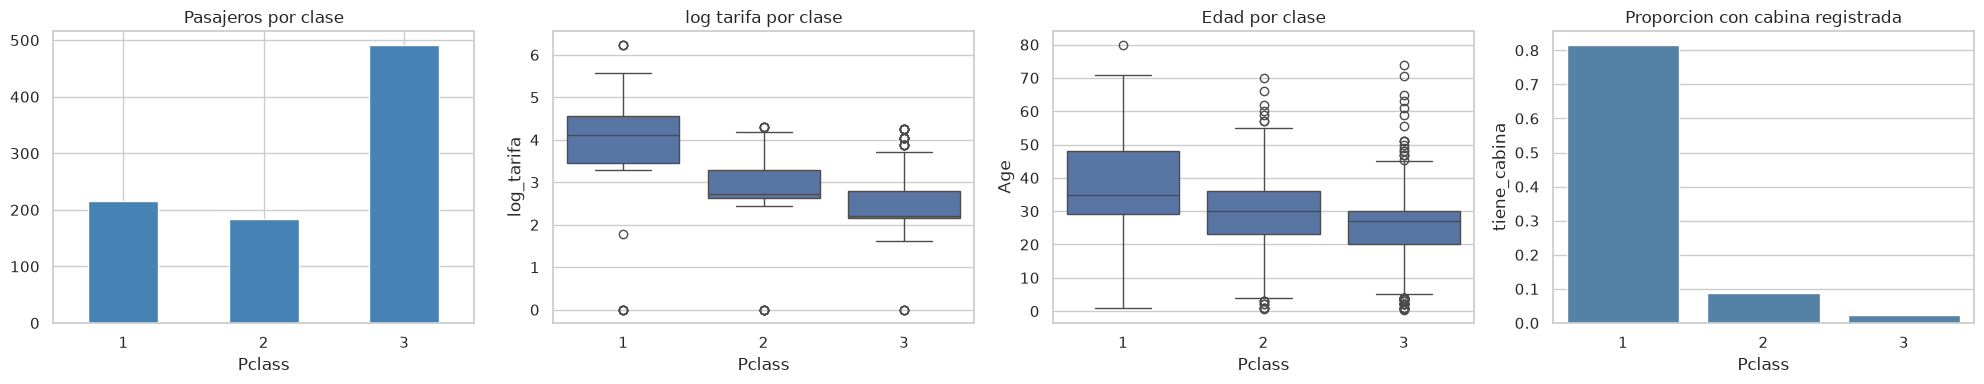

Pclass,1,2,3
Embarked,,,
C,50.6,10.1,39.3
Q,2.6,3.9,93.5
S,20.0,25.4,54.6


In [6]:
fig, ejes = plt.subplots(1, 4, figsize=(20, 4))
df["Pclass"].value_counts().sort_index().plot(kind="bar", ax=ejes[0], rot=0, color="steelblue", title="Pasajeros por clase")
sns.boxplot(data=df, x="Pclass", y="log_tarifa", ax=ejes[1]).set_title("log tarifa por clase")
sns.boxplot(data=df, x="Pclass", y="Age", ax=ejes[2]).set_title("Edad por clase")
sns.barplot(data=df, x="Pclass", y="tiene_cabina", errorbar=None, ax=ejes[3], color="steelblue")
ejes[3].set_title("Proporcion con cabina registrada")
plt.tight_layout()
plt.show()
pd.crosstab(df["Embarked"], df["Pclass"], normalize="index").mul(100).round(1)

Lo que sacamos del análisis exploratorio para el caso multiclase:

1. Las clases no están balanceadas: 491 pasajeros de tercera, 216 de primera y 184 de segunda. Por eso reportamos F1 macro, para que la clase pequeña pese igual.
2. La tarifa separa muy bien las clases: la mediana es de 60 dólares en primera, 14 en segunda y 8 en tercera.
3. El 81 % de los pasajeros de primera tiene cabina registrada, contra 9 % en segunda y 2 % en tercera. `tiene_cabina` va a ser casi un indicador directo de primera clase.
4. Los pasajeros de primera eran mayores (mediana de 35 años contra 27 en tercera).
5. El puerto también dice algo: el 93.5 % de los que subieron en Queenstown iba en tercera, y en Cherbourg la mitad iba en primera.

### División, métricas y control del sobreajuste

Separamos 80 % y 20 % estratificando por el objetivo de cada caso. Las métricas son las mismas de regresión logística. En el caso multiclase, precision, recall y F1 se promedian con **macro average** (todas las clases pesan igual).

**Sobreajuste.** Cuando el modelo aprende el ruido del entrenamiento, la métrica de entrenamiento queda muy por encima de la de prueba. Lo controlamos con `min_samples_leaf`, el mínimo de pasajeros por hoja, escogido con validación cruzada de 5 particiones solo sobre el entrenamiento.

In [7]:
N_ARBOLES = 300
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)


def crear_rf(hoja=1):
    return RandomForestClassifier(n_estimators=N_ARBOLES, min_samples_leaf=hoja, random_state=SEMILLA, n_jobs=-1)


def logistica():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))


def elegir_hoja(train, columnas, objetivo, scoring, opciones=(1, 3, 5, 10, 20)):
    # Validacion cruzada dentro del entrenamiento para escoger min_samples_leaf
    puntajes = {h: cross_val_score(crear_rf(h), train[columnas], train[objetivo], cv=cv, scoring=scoring).mean()
                for h in opciones}
    mejor = max(puntajes, key=puntajes.get)
    print("F1 en validacion cruzada:", {k: round(float(v), 4) for k, v in puntajes.items()}, "| elegido:", mejor)
    return mejor


def evaluar(modelo, train, test, columnas, objetivo, nombre, etiquetas, mostrar=True):
    modelo.fit(train[columnas], train[objetivo])
    pred = modelo.predict(test[columnas])
    promedio = "binary" if len(etiquetas) == 2 else "macro"
    met = {
        "modelo": nombre,
        "n_variables": len(columnas),
        "accuracy_train": accuracy_score(train[objetivo], modelo.predict(train[columnas])),
        "accuracy": accuracy_score(test[objetivo], pred),
        "precision": precision_score(test[objetivo], pred, average=promedio),
        "recall": recall_score(test[objetivo], pred, average=promedio),
        "f1": f1_score(test[objetivo], pred, average=promedio),
    }
    if mostrar:
        fig, eje = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay(confusion_matrix(test[objetivo], pred), display_labels=etiquetas).plot(
            ax=eje, cmap="Greens", colorbar=False)
        eje.set_title(nombre)
        plt.show()
        print(classification_report(test[objetivo], pred, target_names=etiquetas, digits=3))
    return modelo, pred, met


ETQ_BIN = ["murio", "sobrevivio"]
train, test = train_test_split(df, test_size=0.2, random_state=SEMILLA, stratify=df["Survived"])
print("Entrenamiento:", len(train), "| Prueba:", len(test))

Entrenamiento: 712 | Prueba: 179


## 4. Caso 1: Random Forest con una variable

**Enunciado.** Resolver el caso 1 de regresión logística con Random Forest y obtener las métricas.

**Objetivo:** `Survived`. **Característica:** `sexo`.

F1 en validacion cruzada: {1: 0.7143, 3: 0.7143, 5: 0.7143, 10: 0.7143, 20: 0.7143} | elegido: 1


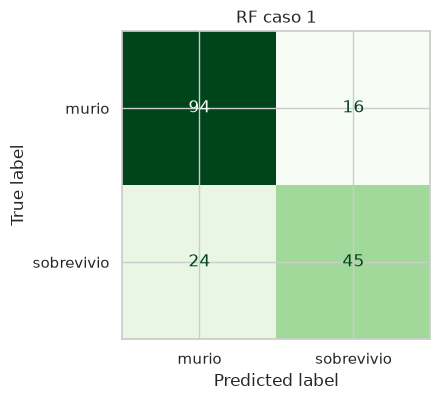

              precision    recall  f1-score   support

       murio      0.797     0.855     0.825       110
  sobrevivio      0.738     0.652     0.692        69

    accuracy                          0.777       179
   macro avg      0.767     0.753     0.758       179
weighted avg      0.774     0.777     0.774       179



,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
Logistica caso 1,1,0.7893,0.7765,0.7377,0.6522,0.6923
RF caso 1,1,0.7893,0.7765,0.7377,0.6522,0.6923


In [8]:
hoja_1 = elegir_hoja(train, ["sexo"], "Survived", "f1")
rf_1, pred_1, met_1 = evaluar(crear_rf(hoja_1), train, test, ["sexo"], "Survived", "RF caso 1", ETQ_BIN)
_, _, met_1_log = evaluar(logistica(), train, test, ["sexo"], "Survived", "Logistica caso 1", ETQ_BIN, mostrar=False)
pd.DataFrame([met_1_log, met_1]).set_index("modelo").round(4)

### Conclusiones del caso 1

El Random Forest da exactamente las mismas métricas que la regresión logística (accuracy de 0.777 y F1 de 0.692). Con una sola variable binaria solo hay dos grupos posibles, hombres y mujeres, y cualquier modelo termina prediciendo la clase mayoritaria de cada grupo. Por eso la validación cruzada da el mismo resultado para cualquier `min_samples_leaf`. La ventaja de Random Forest solo aparece cuando hay variables continuas o combinaciones de variables.

## 5. Caso 2: Random Forest con varias variables

**Enunciado.** Resolver el caso 2 de regresión logística con Random Forest y después con todas las columnas característica.

1. **Parte A:** `sexo` y `Pclass`, las mismas dos variables de la regresión logística.
2. **Parte B:** todas las columnas característica.

F1 en validacion cruzada: {1: 0.6616, 3: 0.6616, 5: 0.6616, 10: 0.6616, 20: 0.6616} | elegido: 1


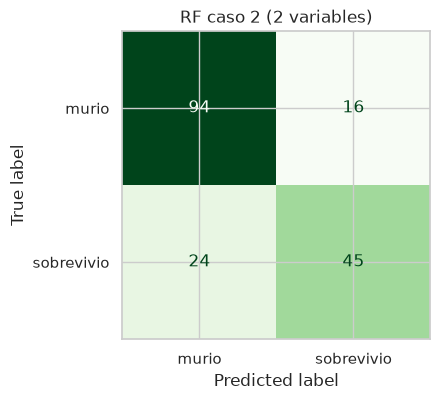

              precision    recall  f1-score   support

       murio      0.797     0.855     0.825       110
  sobrevivio      0.738     0.652     0.692        69

    accuracy                          0.777       179
   macro avg      0.767     0.753     0.758       179
weighted avg      0.774     0.777     0.774       179



In [9]:
cols_2 = ["sexo", "Pclass"]
hoja_2 = elegir_hoja(train, cols_2, "Survived", "f1")
rf_2, pred_2, met_2 = evaluar(crear_rf(hoja_2), train, test, cols_2, "Survived", "RF caso 2 (2 variables)", ETQ_BIN)

F1 en validacion cruzada: {1: 0.7615, 3: 0.7522, 5: 0.7445, 10: 0.7577, 20: 0.7482} | elegido: 1


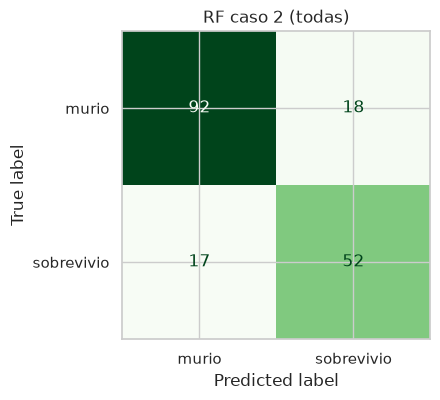

              precision    recall  f1-score   support

       murio      0.844     0.836     0.840       110
  sobrevivio      0.743     0.754     0.748        69

    accuracy                          0.804       179
   macro avg      0.793     0.795     0.794       179
weighted avg      0.805     0.804     0.805       179



In [10]:
todas = ["sexo", "Pclass", "Age", "edad_faltante", "SibSp", "Parch", "tamano_familia", "viaja_solo",
         "log_tarifa", "tiene_cabina"] + cols_puerto + cols_titulo
hoja_t = elegir_hoja(train, todas, "Survived", "f1")
rf_t, pred_t, met_t = evaluar(crear_rf(hoja_t), train, test, todas, "Survived", "RF caso 2 (todas)", ETQ_BIN)

In [11]:
_, _, met_2_log = evaluar(logistica(), train, test, cols_2, "Survived", "Logistica 2 variables", ETQ_BIN, mostrar=False)
_, _, met_t_log = evaluar(logistica(), train, test, todas, "Survived", "Logistica todas", ETQ_BIN, mostrar=False)
tabla_2 = pd.DataFrame([met_1_log, met_1, met_2_log, met_2, met_t_log, met_t]).set_index("modelo").round(4)
tabla_2

,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
Logistica caso 1,1,0.7893,0.7765,0.7377,0.6522,0.6923
RF caso 1,1,0.7893,0.7765,0.7377,0.6522,0.6923
Logistica 2 variables,2,0.7893,0.7765,0.7377,0.6522,0.6923
RF caso 2 (2 variables),2,0.7893,0.7765,0.7377,0.6522,0.6923
Logistica todas,18,0.8329,0.8436,0.8060,0.7826,0.7941
RF caso 2 (todas),18,0.9874,0.8045,0.7429,0.7536,0.7482


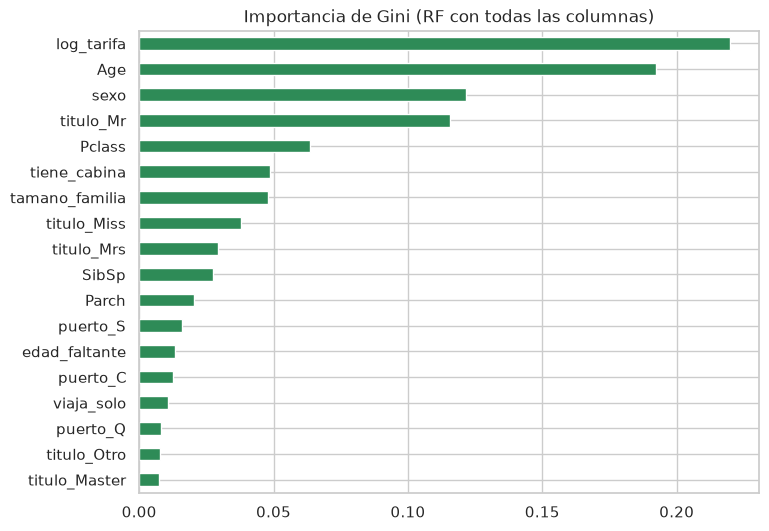

In [12]:
imp = pd.Series(rf_t.feature_importances_, index=todas).sort_values()
imp.plot(kind="barh", figsize=(8, 6), color="seagreen")
plt.title("Importancia de Gini (RF con todas las columnas)")
plt.show()

### Conclusiones del caso 2

**Parte A.** Con sexo y clase, el Random Forest vuelve a coincidir con la regresión logística. Hay solo 6 combinaciones posibles, y en ninguna la proporción de sobrevivientes cambia de lado respecto a lo que ya decía el sexo. Las mujeres de tercera clase están justo en 50 %.

**Parte B.** Con todas las columnas el Random Forest llega a un accuracy de **0.804** y un F1 de **0.748**. Aquí la regresión logística le gana (0.844 y 0.794). El Random Forest tiene un accuracy de entrenamiento de 0.987, contra 0.804 en prueba: está memorizando buena parte del entrenamiento. La validación cruzada escogió hojas de tamaño 1, pero las diferencias entre opciones fueron pequeñas y el conjunto de prueba tiene solo 179 pasajeros, donde cada pasajero vale 0.56 puntos de accuracy.

La conclusión es que en un dataset pequeño y con relaciones bastante simples (sexo, clase, edad), un modelo lineal bien alimentado puede superar a Random Forest. Las variables más importantes fueron la tarifa, la edad, el sexo y el título `Mr`.

## 6. Caso 3: Random Forest multiclase

**Enunciado.** Seleccionar todas las columnas característica y una variable objetivo multiclase, obtener las métricas y remover las columnas necesarias para mejorarlas.

**Objetivo:** `Pclass` (primera, segunda o tercera clase). **Características:** todas las demás columnas, incluyendo `Survived`, que ahora pasa a ser una entrada.

F1 en validacion cruzada: {1: 0.9139, 3: 0.8952, 5: 0.8906, 10: 0.8636, 20: 0.8194} | elegido: 1


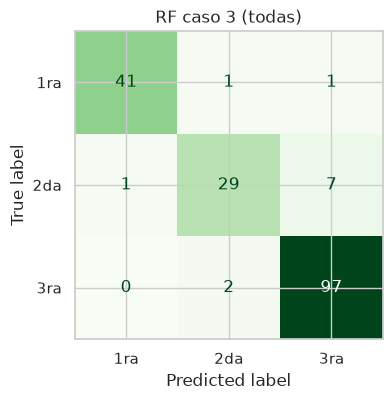

              precision    recall  f1-score   support

         1ra      0.976     0.953     0.965        43
         2da      0.906     0.784     0.841        37
         3ra      0.924     0.980     0.951        99

    accuracy                          0.933       179
   macro avg      0.935     0.906     0.919       179
weighted avg      0.933     0.933     0.931       179



In [13]:
# Nueva division estratificada por la clase del pasajero
train3, test3 = train_test_split(df, test_size=0.2, random_state=SEMILLA, stratify=df["Pclass"])
ETQ_MULTI = ["1ra", "2da", "3ra"]
todas_3 = ["Survived"] + [c for c in todas if c != "Pclass"]

hoja_3 = elegir_hoja(train3, todas_3, "Pclass", "f1_macro")
rf_3, pred_3, met_3 = evaluar(crear_rf(hoja_3), train3, test3, todas_3, "Pclass", "RF caso 3 (todas)", ETQ_MULTI)

### Eliminación de columnas

Usamos la importancia de Gini del modelo para ordenar las columnas y probamos quitar las menos importantes con varios umbrales. Cada opción se evalúa con validación cruzada en el entrenamiento, y la ganadora se prueba una sola vez con el conjunto de prueba.

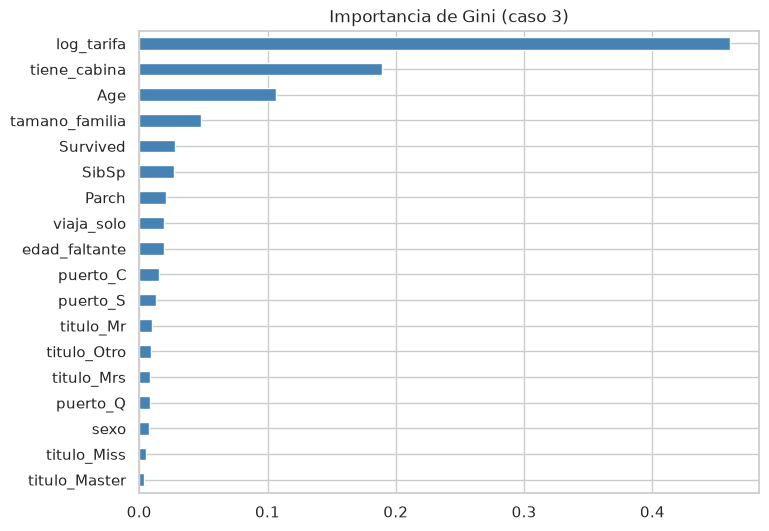

,umbral,n_columnas,f1_macro_cv
0,0.00,18,0.9139
1,0.01,11,0.9262
2,0.02,7,0.9377
3,0.03,4,0.9442
4,0.05,3,0.8902


In [14]:
imp_3 = pd.Series(rf_3.feature_importances_, index=todas_3).sort_values()
imp_3.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Importancia de Gini (caso 3)")
plt.show()

filas = []
for u in [0, 0.01, 0.02, 0.03, 0.05]:
    cols_u = [c for c in todas_3 if imp_3[c] >= u]
    f1_cv = cross_val_score(crear_rf(hoja_3), train3[cols_u], train3["Pclass"], cv=cv, scoring="f1_macro").mean()
    filas.append({"umbral": u, "n_columnas": len(cols_u), "f1_macro_cv": f1_cv})
tabla_u = pd.DataFrame(filas)
tabla_u.round(4)

Umbral elegido: 0.03 | columnas: 4
Columnas eliminadas: ['Parch', 'SibSp', 'Survived', 'edad_faltante', 'puerto_C', 'puerto_Q', 'puerto_S', 'sexo', 'titulo_Master', 'titulo_Miss', 'titulo_Mr', 'titulo_Mrs', 'titulo_Otro', 'viaja_solo']


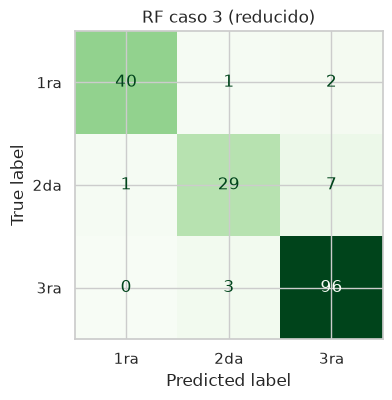

              precision    recall  f1-score   support

         1ra      0.976     0.930     0.952        43
         2da      0.879     0.784     0.829        37
         3ra      0.914     0.970     0.941        99

    accuracy                          0.922       179
   macro avg      0.923     0.895     0.907       179
weighted avg      0.922     0.922     0.921       179



,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
RF caso 3 (todas),18,0.9986,0.9330,0.9354,0.9057,0.9188
RF caso 3 (reducido),4,0.9986,0.9218,0.9229,0.8946,0.9074


In [15]:
mejor_u = tabla_u.loc[tabla_u["f1_macro_cv"].idxmax(), "umbral"]
cols_final = [c for c in todas_3 if imp_3[c] >= mejor_u]
print(f"Umbral elegido: {mejor_u} | columnas: {len(cols_final)}")
print("Columnas eliminadas:", sorted(set(todas_3) - set(cols_final)))
rf_3b, pred_3b, met_3b = evaluar(crear_rf(hoja_3), train3, test3, cols_final, "Pclass", "RF caso 3 (reducido)", ETQ_MULTI)
pd.DataFrame([met_3, met_3b]).set_index("modelo").round(4)

### Conclusiones del caso 3

Predecir la clase del pasajero resulta mucho más fácil que predecir la supervivencia. Con todas las columnas el modelo llega a un accuracy de **0.933** y un F1 macro de **0.919**. La clase más difícil es segunda (recall de 0.784), porque sus tarifas y edades quedan entre primera y tercera. El accuracy de entrenamiento es 0.999, así que el modelo memoriza el entrenamiento, pero en prueba se mantiene por encima de 0.93.

**Eliminación de columnas.** En validación cruzada, quitar columnas mejora el F1 de 0.914 (18 columnas) a 0.944 (4 columnas: tarifa, edad, cabina y tamaño de familia). Si se quitan demasiadas (umbral de 0.05, 3 columnas) el F1 cae a 0.890. En prueba el modelo reducido saca 0.907 de F1 macro contra 0.919 del modelo completo. Esa diferencia es de 2 pasajeros de 179 y está dentro del ruido. La validación cruzada usa 712 pasajeros en 5 particiones, así que es una estimación más confiable.

En resumen, con solo 4 de las 18 columnas se obtiene prácticamente el mismo desempeño. El sexo, el título, el puerto y la supervivencia no aportan nada que la tarifa y la cabina no digan ya.

## 7. Conclusiones generales

1. En el Titanic la regresión logística le ganó a Random Forest en el caso binario con todas las variables. Con pocos datos y relaciones simples, un modelo más complejo no siempre es mejor.
2. Con variables binarias (casos 1 y 2A) los dos modelos son equivalentes, porque las predicciones posibles son las mismas.
3. Para predecir la clase del pasajero, la tarifa y la cabina bastan. Eliminar columnas redundantes dejó un modelo mucho más simple sin perder desempeño real.